In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import MeanShift,estimate_bandwidth
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [13]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 5.Clusstering Mean Shift Algorithms

In [14]:
df = df.drop(columns='CustomerID')

In [15]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas") # Tambahkan baris ini sebelum fit_transform
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


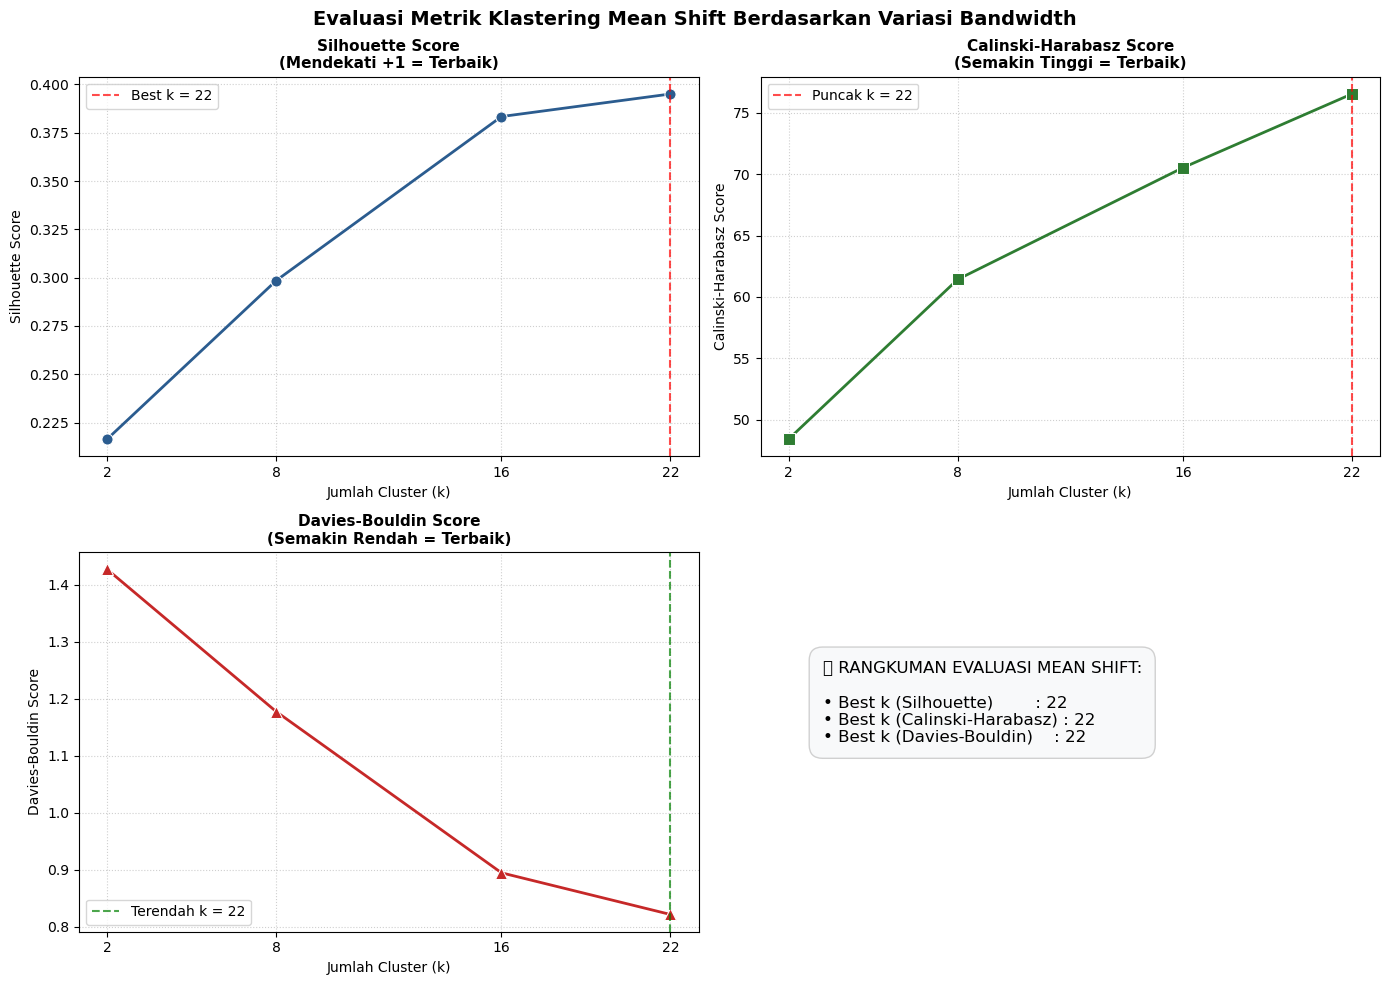

,n_clusters(k),bandwidth,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,2,1.470596,0.216549,48.432170,1.426884
1,8,1.278779,0.298511,61.424804,1.177491
2,16,1.086963,0.383361,70.524285,0.894677
3,22,0.895146,0.395038,76.529201,0.821594


In [ ]:
estimated_bw = estimate_bandwidth(X_cleaned, quantile=0.2, n_samples=len(X_cleaned))
bandwidth_range = np.linspace(estimated_bw * 0.5, estimated_bw * 2.0, 15)

sil_scores = []
ch_scores = []
db_scores = []
bw_list = []
nclusters = []


for bw in bandwidth_range:
    ms = MeanShift(bandwidth=bw, bin_seeding=True).fit(X_cleaned)
    labels = ms.labels_
    n_clusters = len(set(labels))
    
    if 1 < n_clusters < len(X_cleaned): # Hanya simpan jika jumlah klaster valid (1 < k < N)
        sil_scores.append(silhouette_score(X_cleaned, labels))
        ch_scores.append(calinski_harabasz_score(X_cleaned, labels))
        db_scores.append(davies_bouldin_score(X_cleaned, labels))
        bw_list.append(bw)
        nclusters.append(n_clusters)

df_scores = pd.DataFrame({
    'n_clusters(k)': nclusters,
    'bandwidth': bw_list,
    'Silhouette Score': sil_scores,
    'Calinski-Harabasz Score': ch_scores,
    'Davies-Bouldin Score': db_scores
})
df_scores = df_scores.drop_duplicates(subset=['n_clusters(k)']).sort_values('n_clusters(k)').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
k_ticks = df_scores['n_clusters(k)'].values

# --- Plot 1: Silhouette Score (axes[0, 0]) ---
best_k_sil = int(df_scores.loc[df_scores['Silhouette Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 0], x='n_clusters(k)', y='Silhouette Score', data=df_scores, marker='o', markersize=8, linewidth=2, color='#2b5c8f')
axes[0, 0].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k_sil}')
axes[0, 0].set_title('Silhouette Score\n(Mendekati +1 = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Cluster (k)')
axes[0, 0].set_xticks(k_ticks)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()

# --- Plot 2: Calinski-Harabasz Score axes[0, 1]) ---
best_k_ch = int(df_scores.loc[df_scores['Calinski-Harabasz Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 1], x='n_clusters(k)', y='Calinski-Harabasz Score', data=df_scores, marker='s', markersize=8, linewidth=2, color='#2e7d32')
axes[0, 1].axvline(x=best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Puncak k = {best_k_ch}')
axes[0, 1].set_title('Calinski-Harabasz Score\n(Semakin Tinggi = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Cluster (k)')
axes[0, 1].set_xticks(k_ticks)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()

# --- Plot 3: Davies-Bouldin Score (axes[1, 0]) ---
best_k_db = int(df_scores.loc[df_scores['Davies-Bouldin Score'].idxmin(), 'n_clusters(k)'])
sns.lineplot(ax=axes[1, 0], x='n_clusters(k)', y='Davies-Bouldin Score', data=df_scores, marker='^', markersize=8, linewidth=2, color='#c62828')
axes[1, 0].axvline(x=best_k_db, color='green', linestyle='--', alpha=0.7, label=f'Terendah k = {best_k_db}')
axes[1, 0].set_title('Davies-Bouldin Score\n(Semakin Rendah = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Cluster (k)')
axes[1, 0].set_xticks(k_ticks)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()

# --- Plot 4: Summary Text (axes[1, 1]) ---
axes[1, 1].axis('off')
summary_text = (f"📌 RANGKUMAN EVALUASI MEAN SHIFT:\n\n"f"• Best k (Silhouette)        : {best_k_sil}\n"f"• Best k (Calinski-Harabasz) : {best_k_ch}\n"f"• Best k (Davies-Bouldin)    : {best_k_db}")
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12,bbox=dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="#cccccc", alpha=0.9))

plt.suptitle('Evaluasi Metrik Klastering Mean Shift Berdasarkan Variasi Bandwidth', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
df_scores